# Laboratorio 8

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import random
import pyreadr
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_predict
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('ggplot')

In [2]:
result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### 1. Conjuntos Train y Test

In [3]:
#Limpieza de datos

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")

df = df.dropna(subset=["price"])

In [4]:
def categorize_price(price):
    if price <= 120:
        return "Economico"
    elif price <= 326:
        return "Intermedio"
    else:
        return "Caro"

df["price_category"] = df["price"].apply(categorize_price)

/var/folders/dc/_dt3fhrs48n2b_4mmncch3440000gp/T/ipykernel_20035/3701250134.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_category"] = df["price"].apply(categorize_price)


In [5]:
df['price_category'].value_counts()

price_category
Intermedio    37882
Economico     19310
Caro          19054
Name: count, dtype: int64

In [6]:
# variables predictoras
X = df.drop(columns=["price", "price_category"])

# variable objetivo (clasificación)
y = df["price_category"]

In [7]:
X = df.select_dtypes(include=['int64', 'float64'])

In [8]:
X.dtypes

id                             float64
scrape_id                      float64
latitude                       float64
longitude                      float64
bathrooms                      float64
price                          float64
minimum_nights_avg_ntm         float64
maximum_nights_avg_ntm         float64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location         float64
review_scores_value            float64
reviews_per_month              float64
dtype: object

In [9]:
pd.Series(y).value_counts(normalize=True)

price_category
Intermedio    0.496839
Economico     0.253259
Caro          0.249902
Name: proportion, dtype: float64

In [10]:
important_cols = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating"
]

X = df[important_cols]

In [11]:
# variables importantes
X = df[[
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "review_scores_rating"
]]

y = df["price_category"]

# imputar
from sklearn.impute import SimpleImputer
X = SimpleImputer(strategy="mean").fit_transform(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


### 2. Exploración y Transformación

In [12]:
# escalar
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Variable Respuesta

Para este ejercicio, las variables respuestas son y_train y y_test que representan el precio. Estas representan:
 - Económico
 - Intermedio
- Caro

### 4. Modelos SVM y 5. Predicción con modelos entrenados

In [16]:
# RBF
svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6164203899624028


In [17]:
# LINEAL
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train_scaled, y_train)

y_pred_lin = svm_linear.predict(X_test_scaled)
acc_lin = accuracy_score(y_test, y_pred_lin)

print("Accuracy:", acc_lin)


Accuracy: 0.6057095392148291


In [15]:
# POLINOMIAL
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train_scaled, y_train)

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, y_pred_poly)

print("Accuracy:", acc_poly)


Accuracy: 0.578517093643438


### 6. Matrices de confusión

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# Modelo 1 
cm_rbf = confusion_matrix(y_test, y_pred)

# Modelo 2 
cm_lin = confusion_matrix(y_test, y_pred_lin)

# Modelo 3 
cm_poly = confusion_matrix(y_test, y_pred_poly)

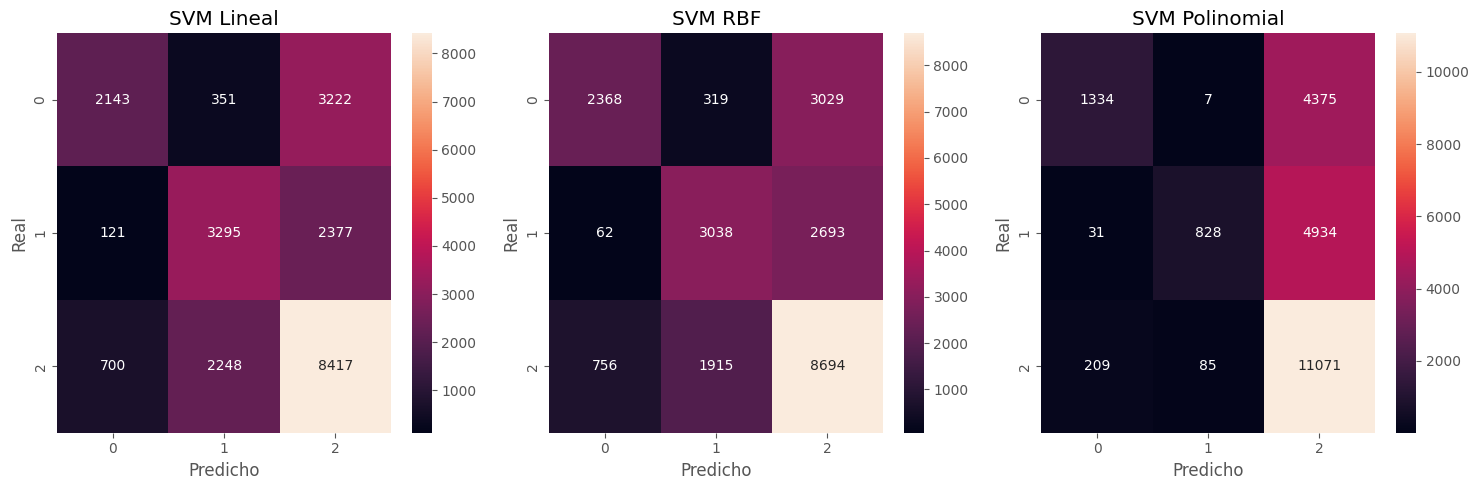

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.heatmap(cm_lin, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("SVM Lineal")

sns.heatmap(cm_rbf, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("SVM RBF")

sns.heatmap(cm_poly, annot=True, fmt='d', ax=axes[2])
axes[2].set_title("SVM Polinomial")

for ax in axes:
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

### 7. Modelos Desajustados o Sobreajustados

In [27]:
from sklearn.metrics import accuracy_score

y_train_pred = svm.predict(X_train_scaled)

# Accuracy
acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_pred)

print("Train:", acc_train)
print("Test:", acc_test)

Train: 0.6120250318519074
Test: 0.6164203899624028


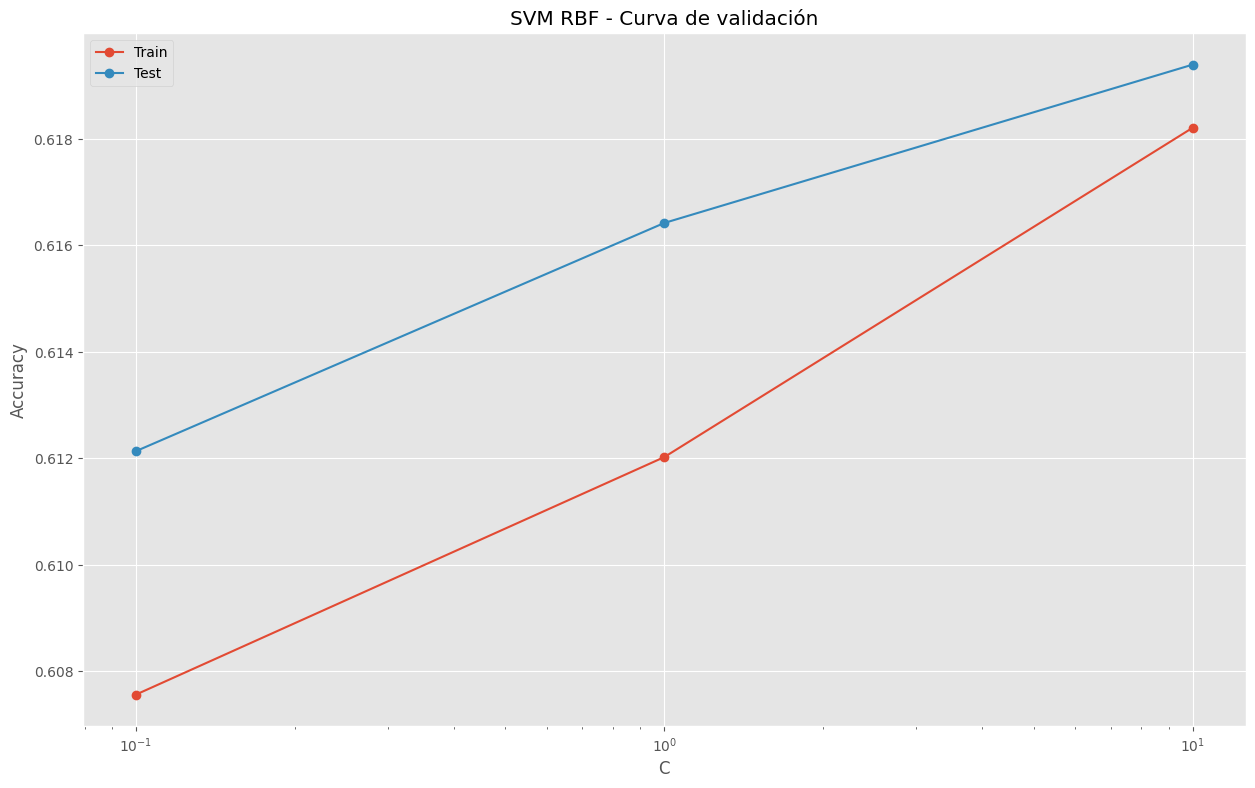

In [33]:
C_values = [0.1, 1, 10]

train_acc_rbf = []
test_acc_rbf = []

for C in C_values:
    svm_rbf = SVC(kernel='rbf', C=C)
    svm_rbf.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_rbf.predict(X_train_scaled)
    y_test_pred = svm_rbf.predict(X_test_scaled)
    
    train_acc_rbf.append(accuracy_score(y_train, y_train_pred))
    test_acc_rbf.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_rbf, marker='o', label='Train')
plt.plot(C_values, test_acc_rbf, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM RBF - Curva de validación")
plt.legend()
plt.show()

In [28]:
y_train_pred_lin = svm_linear.predict(X_train_scaled)

acc_train_lin = accuracy_score(y_train, y_train_pred_lin)
acc_test_lin = accuracy_score(y_test, y_pred)

print("Train:", acc_train_lin)
print("Test:", acc_test_lin)

Train: 0.599640260810912
Test: 0.6164203899624028


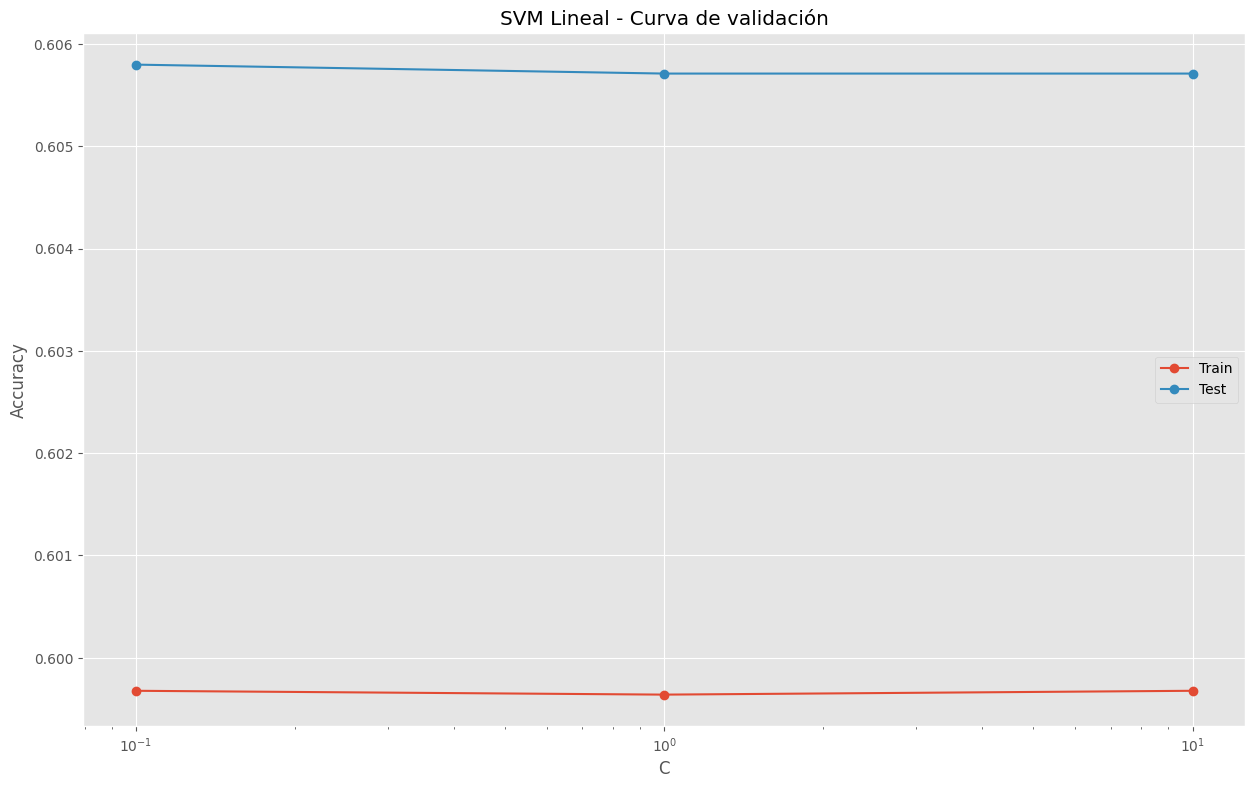

In [34]:
C_values = [0.1, 1, 10]

train_acc_lin = []
test_acc_lin = []

for C in C_values:
    svm_lin = SVC(kernel='linear', C=C)
    svm_lin.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_lin.predict(X_train_scaled)
    y_test_pred = svm_lin.predict(X_test_scaled)
    
    train_acc_lin.append(accuracy_score(y_train, y_train_pred))
    test_acc_lin.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(C_values, train_acc_lin, marker='o', label='Train')
plt.plot(C_values, test_acc_lin, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Lineal - Curva de validación")
plt.legend()
plt.show()

In [29]:
y_train_pred_poly = svm_poly.predict(X_train_scaled)

acc_train_poly = accuracy_score(y_train, y_train_pred_poly)
acc_test_poly = accuracy_score(y_test, y_pred)

print("Train:", acc_train_poly)
print("Test:", acc_test_poly)

Train: 0.5782994828749157
Test: 0.6164203899624028


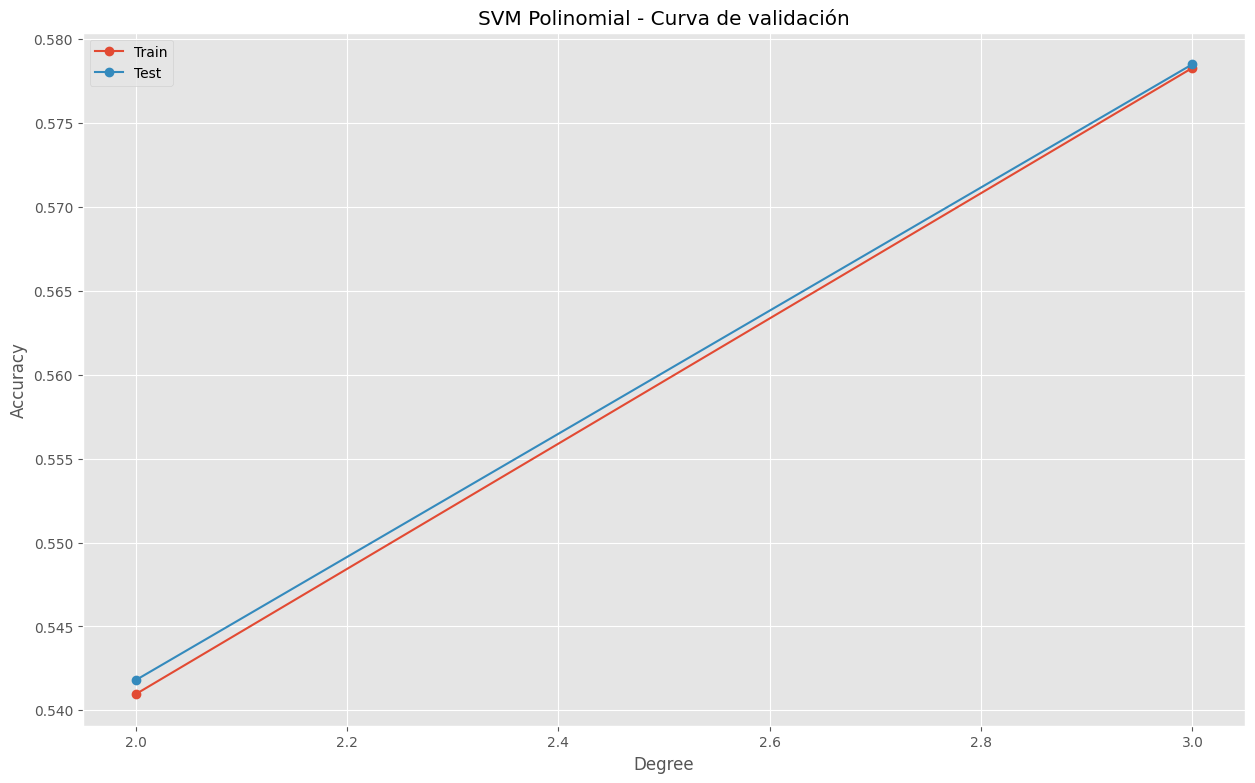

In [35]:
degrees = [2, 3]

train_acc_poly = []
test_acc_poly = []

for d in degrees:
    svm_poly = SVC(kernel='poly', degree=d, C=1)
    svm_poly.fit(X_train_scaled, y_train)
    
    y_train_pred = svm_poly.predict(X_train_scaled)
    y_test_pred = svm_poly.predict(X_test_scaled)
    
    train_acc_poly.append(accuracy_score(y_train, y_train_pred))
    test_acc_poly.append(accuracy_score(y_test, y_test_pred))

plt.figure()
plt.plot(degrees, train_acc_poly, marker='o', label='Train')
plt.plot(degrees, test_acc_poly, marker='o', label='Test')

plt.xlabel("Degree")
plt.ylabel("Accuracy")
plt.title("SVM Polinomial - Curva de validación")
plt.legend()
plt.show()

### 8. Comparación modelos con respecto a efectividad, tiempo y errores

In [36]:
import time

start = time.time()

svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train_scaled, y_train)

end = time.time()
tiempo_rbf = end - start

print("Tiempo RBF:", tiempo_rbf)

Tiempo RBF: 40.139047145843506


In [37]:
start = time.time()

svm_lin = SVC(kernel='linear')
svm_lin.fit(X_train_scaled, y_train)

end = time.time()
tiempo_lin = end - start

print("Tiempo Lineal:", tiempo_lin)

Tiempo Lineal: 34.064109086990356


In [38]:
start = time.time()

svm_poly = SVC(kernel='poly', degree=3)
svm_poly.fit(X_train_scaled, y_train)

end = time.time()
tiempo_poly = end - start

print("Tiempo Polinomial:", tiempo_poly)

Tiempo Polinomial: 121.94523787498474


In [39]:
print("\nComparación de tiempos:")
print("Lineal:", tiempo_lin)
print("RBF:", tiempo_rbf)
print("Polinomial:", tiempo_poly)


Comparación de tiempos:
Lineal: 34.064109086990356
RBF: 40.139047145843506
Polinomial: 121.94523787498474


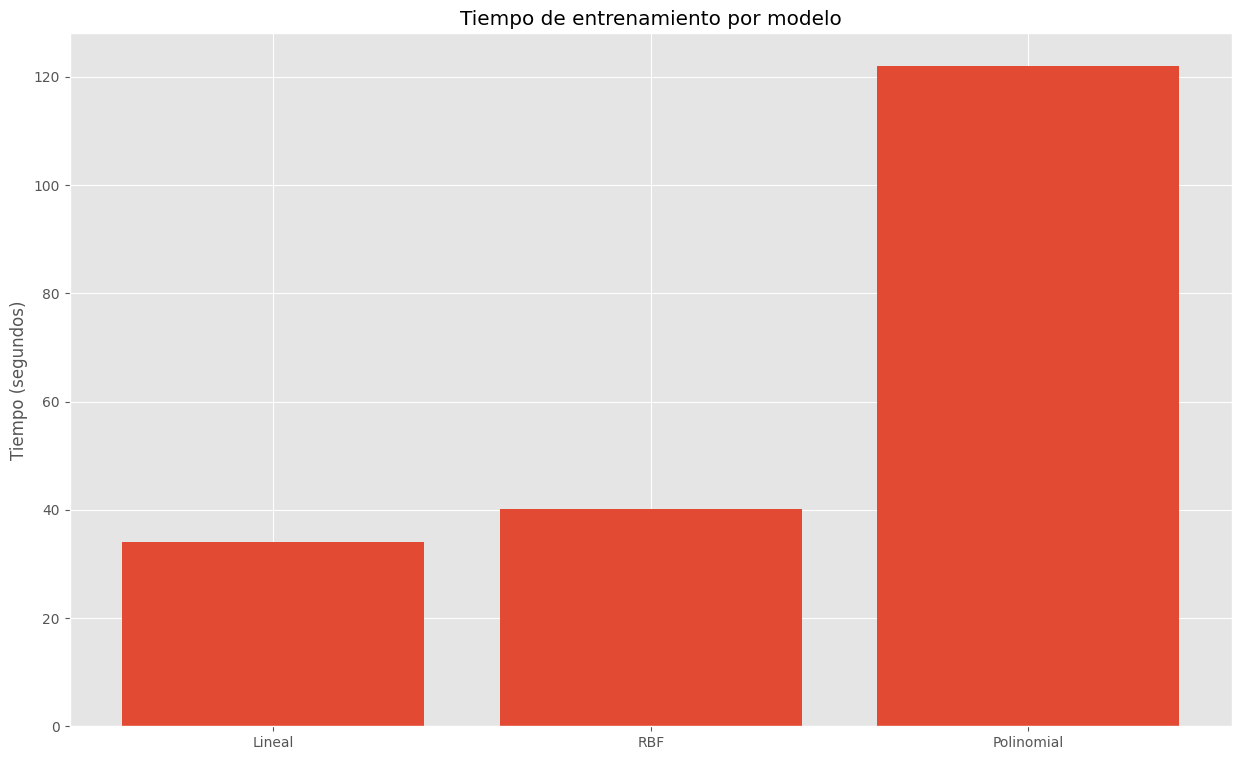

In [40]:
modelos = ['Lineal', 'RBF', 'Polinomial']
tiempos = [tiempo_lin, tiempo_rbf, tiempo_poly]

plt.figure()
plt.bar(modelos, tiempos)
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de entrenamiento por modelo")
plt.show()